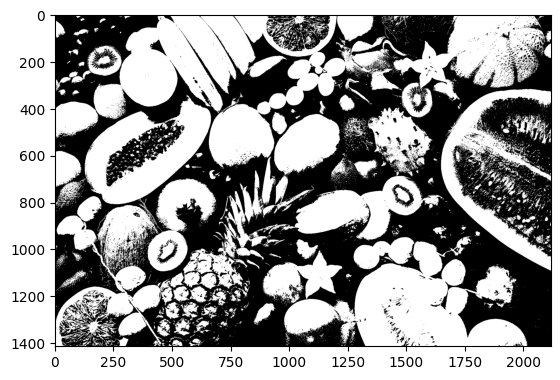

In [1]:
from PIL import Image                       # Thư viện xử lý ảnh PIL
import numpy as np                          # Thư viện mảng số
import imageio.v2 as iio                    # (Không dùng trong đoạn này)
import scipy.ndimage as nd                  # (Không dùng trong đoạn này)
import matplotlib.pylab as plt              # Thư viện vẽ đồ thị
from skimage.filters.thresholding import threshold_otsu  # Hàm ngưỡng Otsu

# Đọc ảnh 'fruit.jpg' và chuyển sang ảnh xám (grayscale)
data = Image.open('exercise/fruit.jpg').convert('L')

# Chuyển ảnh thành mảng numpy
a = np.asarray(data)

# Thực hiện phân ngưỡng Otsu để tìm ngưỡng tối ưu
thres = threshold_otsu(a)

# Tạo ảnh nhị phân: giữ lại các pixel có cường độ > ngưỡng
b = a > thres

# Chuyển mảng nhị phân (True/False) sang ảnh
b = Image.fromarray(b)

# Hiển thị ảnh kết quả
plt.imshow(b)
plt.show()


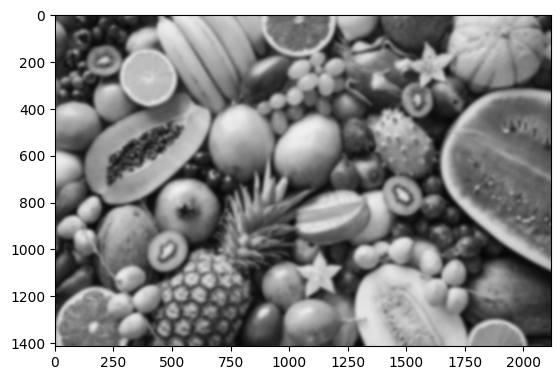

In [4]:
from PIL import Image                        # Thư viện xử lý ảnh
import numpy as np                           # Thư viện xử lý mảng số
import imageio.v2 as iio                     # (Không dùng trong đoạn này)
import scipy.ndimage as nd                   # (Không dùng trong đoạn này)
import matplotlib.pylab as plt               # Thư viện vẽ ảnh
from skimage.filters import threshold_local  # Hàm tính ngưỡng cục bộ (local)

# Đọc ảnh 'fruit.jpg' và chuyển sang ảnh xám (grayscale)
data = Image.open('exercise/fruit.jpg').convert('L')

# Chuyển ảnh sang mảng numpy
a = np.asarray(data)

# Thực hiện phân ngưỡng cục bộ (local thresholding)
# window_size=39: kích thước cửa sổ, offset=10: dịch ngưỡng lên thêm 10
b = threshold_local(a, 39, offset=10)

# Chuyển mảng kết quả sang ảnh
b = Image.fromarray(b)

plt.imshow(b)
plt.show()


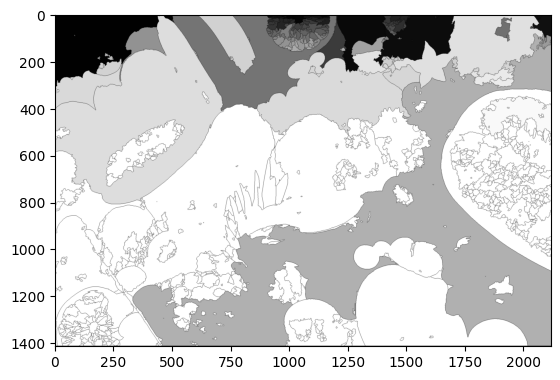

In [5]:
import cv2                                  # Thư viện OpenCV
from PIL import Image                       # Thư viện xử lý ảnh PIL
import numpy as np                          # Thư viện mảng số
import imageio.v2 as iio                     # (Không dùng trong đoạn này)
import scipy.ndimage as nd                  # (Không dùng trong đoạn này)
from scipy.ndimage import label              # Hàm gán nhãn (label)
import matplotlib.pylab as plt              # Thư viện vẽ ảnh
from skimage.filters import threshold_local  # (Không dùng trong đoạn này)

# Mở ảnh và chuyển sang ảnh xám
data = cv2.imread('exercise/fruit.jpg')

# Chuyển ảnh màu sang ảnh xám
a = cv2.cvtColor(data, cv2.COLOR_BGR2GRAY)

# Áp dụng phân ngưỡng Otsu để thu được pixel của vùng quan tâm (cell pixels)
thresh, b1 = cv2.threshold(a, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Vì Otsu không phân đoạn hết ảnh, nên thực hiện phép co (erosion) để làm mảnh vùng foreground
b2 = cv2.erode(b1, None, iterations=2)

# Tính toán ảnh khoảng cách (distance transform)
dist_trans = cv2.distanceTransform(b2, 2, 3)

# Áp dụng phân ngưỡng lên ảnh distance transform để xác định vùng foreground
thresh, dt = cv2.threshold(dist_trans, 1, 255, cv2.THRESH_BINARY)

# Thực hiện gán nhãn (labeling)
labelled, ncc = label(dt)

# Chuyển mảng nhãn sang kiểu số nguyên 32-bit (bắt buộc cho watershed)
labelled = labelled.astype(np.int32)    

# Thực hiện thuật toán watershed (tách vùng)
cv2.watershed(data, labelled)

# Chuyển kết quả gán nhãn thành ảnh để hiển thị
b = Image.fromarray(labelled)

# Hiển thị ảnh kết quả
plt.imshow(b)
plt.show()


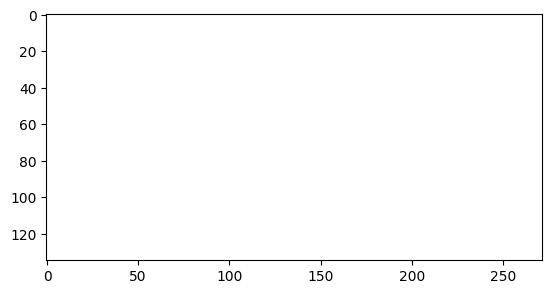

In [3]:
import cv2                                   # Thư viện OpenCV
from PIL import Image                        # Thư viện xử lý ảnh PIL
import numpy as np                           # Thư viện mảng số
import imageio.v2 as iio                     # (Không dùng trong đoạn này)
import scipy.ndimage as nd                   # Thư viện xử lý ảnh nâng cao
from scipy.ndimage import label               # (Không dùng trong đoạn này)
import matplotlib.pylab as plt               # Thư viện vẽ ảnh
from skimage.filters import threshold_local  # (Không dùng trong đoạn này)

# Mở ảnh 'Dil.png' và chuyển sang ảnh xám (grayscale)
data = Image.open('exercise/dil.png').convert('L')

# Thực hiện phép giãn (dilation): làm to vùng trắng lên
b = nd.binary_dilation(data, iterations=50)

# Chuyển mảng kết quả thành ảnh để hiển thị
c = Image.fromarray(b)

# Hiển thị ảnh kết quả
c.show()
plt.imshow(c)
plt.show()


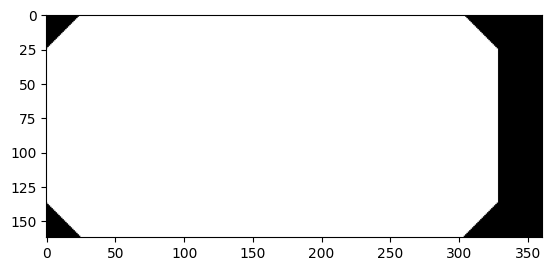

In [ ]:
import cv2                                   # Thư viện OpenCV
from PIL import Image                        # Thư viện xử lý ảnh PIL
import numpy as np                           # Thư viện mảng số
import imageio.v2 as iio                     # (Không dùng trong đoạn này)
import scipy.ndimage as nd                   # Thư viện xử lý ảnh nâng cao
from scipy.ndimage import label               # (Không dùng trong đoạn này)
import matplotlib.pylab as plt               # Thư viện vẽ ảnh
from skimage.filters import threshold_local  # (Không dùng trong đoạn này)

# Mở ảnh 'Dil.png' và chuyển sang ảnh xám (grayscale)
data = Image.open('exercise/dil.png').convert('L')

# Định nghĩa phần tử cấu trúc (structuring element) 3x3
s = [[0, 1, 0],
     [1, 1, 1],
     [0, 1, 0]]

# Thực hiện phép mở (opening): erosion + dilation, giúp loại bỏ nhiễu nhỏ
b = nd.binary_opening(data, structure=s, iterations=25)

# Chuyển mảng kết quả thành ảnh để hiển thị
c = Image.fromarray(b)

# Hiển thị ảnh kết quả
c.show()
plt.imshow(c)
plt.show()


In [ ]:
import scipy.ndimage as nd
from PIL import Image
import numpy as np
import matplotlib.pylab as plt

# Mở ảnh và chuyển sang ảnh xám
data = Image.open('exercise/dil.png').convert('L')
data = np.array(data)

# Định nghĩa phần tử cấu trúc
s = [[0, 1, 0],
     [1, 1, 1],
     [0, 1, 0]]

# Thực hiện phép co (erosion)
b = nd.binary_erosion(data, structure=s, iterations=50)

# Chuyển sang ảnh để hiển thị
c = Image.fromarray((b * 255).astype(np.uint8))

# Hiển thị
c.show()
plt.imshow(c, cmap='gray')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'anh.png'

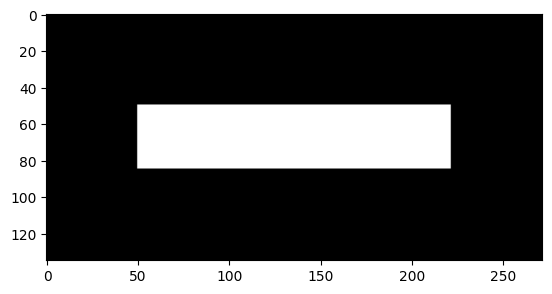

In [4]:
import cv2                                   # Thư viện OpenCV (không dùng trong đoạn này)
from PIL import Image                        # Thư viện xử lý ảnh PIL
import numpy as np                           # Thư viện mảng số
import imageio.v2 as iio                     # (Không dùng trong đoạn này)
import scipy.ndimage as nd                   # Thư viện xử lý ảnh nâng cao
from scipy.ndimage import label               # (Không dùng trong đoạn này)
import matplotlib.pylab as plt               # Thư viện vẽ ảnh
from skimage.filters import threshold_local  # (Không dùng trong đoạn này)

# Mở ảnh 'dil_img.gif' và chuyển sang ảnh xám (grayscale)
data = Image.open('exercise/dil.png').convert('L')

# Định nghĩa phần tử cấu trúc (structuring element)
s = [[0, 1, 0],
     [1, 1, 1],
     [0, 1, 0]]

# Thực hiện phép đóng (closing): dilation rồi erosion, giúp lấp các lỗ nhỏ
b = nd.binary_closing(data, structure=s, iterations=50)

# Chuyển mảng kết quả thành ảnh để hiển thị
c = Image.fromarray(b)

# Hiển thị ảnh kết quả
c.show()
plt.imshow(c)
plt.show()
